# Comprehensive Analysis Document: Market Sentiment & Trading Behavior

This document summarizes the steps taken to analyze the Hyperliquid Historical Trader Data in conjunction with the Fear/Greed Index, detailing the methodology, key findings, and derived insights.

## 1. Analysis Steps Performed

We systematically processed and analyzed the data through the following stages:

*   **Data Loading & Standardization:**
    *   Loaded `historical_data.csv` (trading data) and `fear_greed_index.csv` (sentiment data) into pandas DataFrames.
    *   Standardized the 'Timestamp' column in the historical data and the 'date' column in the sentiment data to a consistent 'YYYY-MM-DD' format, creating a common 'date' key for merging.

*   **Data Cleaning & Merging:**
    *   Removed rows with missing 'Closed PnL' or 'Execution Price' from the historical data (though none were found in this dataset).
    *   Performed a **Left Join** of `df_historical` with `df_fear_greed` on the 'date' column to create `df_merged`.
    *   **Verified the merge** by ensuring row counts remained consistent, confirming no duplicate dates in the sentiment data.
    *   **Forward-filled** any missing sentiment values in `df_merged` to ensure complete sentiment classification for all trades.

*   **Sentiment-Based Profitability Analysis:**
    *   Grouped trades by sentiment 'classification' (Extreme Greed, Fear, Greed, Neutral).
    *   Calculated **Win Rate (%)** and **Profit Factor** for each sentiment category.

*   **Notional Value Analysis by Sentiment (Risk Appetite):**
    *   Calculated 'Notional Value' for each trade (`Size Tokens * Execution Price`).
    *   Analyzed the **average Notional Value** across different sentiment classifications.
    *   Generated a **Box Plot** to visualize the distribution of 'Notional Value' by sentiment as an alternative indicator of risk appetite.

*   **Contrarian Test (Side vs. Sentiment):**
    *   Calculated the **Long/Short Ratio** for each sentiment level.
    *   Compared the **average PnL for 'Long' trades** during 'Extreme Fear' versus 'Extreme Greed'.

*   **"Smart Money" Profiling (Account-Level Analysis):**
    *   Grouped data by 'Account' and calculated total 'Closed PnL' for each user.
    *   **Segmented accounts** into 'Top 10%' (most profitable) and 'Bottom 90%'.
    *   Compared **sentiment distribution** and **Long/Short Ratios** between these two account segments, with a deep dive into behavior during 'Extreme Greed'.

*   **Asset Sensitivity Analysis (Coin-Level):**
    *   Split trades into **Bitcoin (BTC)** and **Altcoins**.
    *   Calculated **Win Rate (%)** and **Profit Factor** for both BTC and Altcoins across sentiment classifications.

*   **Visualizations:**
    *   **Performance Heatmap:** Win Rate (%) by Sentiment Classification and Coin.
    *   **Cumulative PnL vs. Sentiment:** Dual-axis line plot showing Cumulative PnL alongside Fear/Greed Index over time.
    *   **Daily Trade Count vs. Fear/Greed Index:** Dual-axis line plot showing daily trade volume alongside Fear/Greed Index over time.
    *   **Daily Total Notional Value vs. Fear/Greed Index:** Dual-axis line plot showing daily total capital committed alongside Fear/Greed Index over time.

## 2. Analysis Results

### 2.1 Sentiment-Based Profitability Analysis

| Classification | Win Rate (%) | Profit Factor |
|:---------------|:-------------|:--------------|
| Extreme Greed  | 49.01        | 3.22          |
| Fear           | 40.41        | 4.09          |
| Greed          | 44.65        | 7.23          |
| Neutral        | 31.72        | 1.96          |

### 2.2 Notional Value Analysis by Sentiment

| Classification  | Notional Value (Average) |
|:----------------|:-------------------------|
| Extreme Greed   | 5660.27                  |
| Fear            | 6307.41                  |
| Greed           | 3182.88                  |
| Neutral         | 3058.85                  |

### 2.3 Contrarian Test: Long/Short Ratio

**Long/Short Ratio by Sentiment Classification:**

| Classification | BUY   | SELL  | Long/Short Ratio |
|:---------------|:------|:------|:-----------------|
| Extreme Greed  | 3371  | 3591  | 0.94             |
| Fear           | 80399 | 80433 | 1.00             |
| Greed          | 15421 | 20868 | 0.74             |
| Neutral        | 3505  | 3636  | 0.96             |

**Average PnL for Long trades:**

*   Extreme Fear: `nan` (due to insufficient data)
*   Extreme Greed: `25.58`

### 2.4 "Smart Money" Profiling

**Top 10% Most Profitable Accounts (Head of PnL distribution):**

| Account                                    | Total PnL      |
|:-------------------------------------------|:---------------|
| 0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 | 2,143,383      |
| 0x083384f897ee0f19899168e3b1bec365f52a9012 | 1,600,230      |
| 0xbaaaf6571ab7d571043ff1e313a9609a10637864 | 940,164        |

**Sentiment Distribution by Account Segment (% of trades within segment):**

| Account Segment | Extreme Greed (%) | Fear (%)  | Greed (%) | Neutral (%) |
|:----------------|:------------------|:----------|:----------|:------------|
| Bottom 90%      | 2.27              | 74.98     | 19.55     | 3.21        |
| Top 10%         | 7.74              | 81.15     | 6.98      | 4.13        |

**Side Choices and Long/Short Ratio by Account Segment during 'Extreme Greed':**

| Account Segment | BUY   | SELL  | Long/Short Ratio |
|:----------------|:------|:------|:-----------------|
| Bottom 90%      | 1858  | 2028  | 0.92             |
| Top 10%         | 1513  | 1563  | 0.97             |

### 2.5 Asset Sensitivity Analysis (Profitability by Sentiment for BTC vs. Altcoins)

| Classification | BTC Win Rate (%) | BTC Profit Factor | Altcoin Win Rate (%) | Altcoin Profit Factor |
|:---------------|:-----------------|:------------------|:---------------------|:----------------------|
| Extreme Greed  | 27.43            | 0.47              | 54.69                | 3.85                  |
| Fear           | 35.73            | 2.86              | 41.15                | 4.37                  |
| Greed          | 33.71            | 8.32              | 45.39                | 7.20                  |
| Neutral        | 34.56            | 20.28             | 31.63                | 1.90                  |

## 3. Summary & Key Insights

This analysis has uncovered several high-value insights regarding the interplay of market sentiment and trading behavior:

*   **Sentiment's Impact on Profitability:**
    *   'Greed' periods exhibit the highest Profit Factor (7.23), indicating that while not all trades are wins, the profitable ones are significantly larger than losses. 'Extreme Greed' has the highest Win Rate (49.01%), but a lower Profit Factor than 'Greed'.
    *   'Neutral' sentiment appears to be the least favorable, with the lowest Win Rate and Profit Factor.

*   **Risk Appetite (Notional Value):**
    *   Traders tend to deploy the largest average capital ('Notional Value') during periods of 'Fear' and 'Extreme Greed'. This suggests increased conviction or risk-taking when sentiment is at its extremes.
    *   The Box Plot visualization for Notional Value further elaborates on the distribution of capital committed, with potential outliers during extreme sentiments indicating 'gambling' behavior.

*   **Contrarian Behavior:**
    *   The overall Long/Short Ratios are generally balanced across sentiments, except for 'Greed' where SELL trades slightly outnumber BUYs.
    *   The 'Extreme Fear' PnL for long trades could not be definitively compared due to insufficient data for 'long' trades during that period.

*   **"Smart Money" Behavior:**
    *   **Top 10% most profitable accounts are notably more active during 'Extreme Greed'** (7.74% of their trades) compared to the 'Bottom 90%' (2.27%). This suggests successful traders might leverage these periods more actively.
    *   During 'Extreme Greed', 'Top 10%' accounts maintain a more balanced BUY/SELL ratio (0.97) than 'Bottom 90%' accounts (0.92), implying less aggressive 'Longing' or more hedging/selling by the top traders when others might be capitulating or getting overly enthusiastic. This supports the hypothesis that skilled traders avoid being purely directional during peak greed.

*   **Asset Sensitivity:**
    *   **Altcoins show a higher Win Rate** across most sentiments, especially during 'Extreme Greed'.
    *   **Bitcoin (BTC) exhibits exceptionally high Profit Factors** during 'Greed' (8.32) and 'Neutral' (20.28), even with lower Win Rates. This suggests that while BTC trades might be profitable less often, the winning trades are substantially larger, making the Fear/Greed Index a strong indicator for identifying highly lucrative, albeit less frequent, BTC trading opportunities during specific sentiments.

*   **Trading Activity & Sentiment (Visualizations):**
    *   The Cumulative PnL chart provides an 'equity curve' perspective, allowing visual correlation between overall market profitability and sentiment shifts.
    *   The Daily Trade Count and Total Notional Value charts against the Fear/Greed Index offer insights into how trading frequency and capital deployment react to changing market psychology, further illuminating periods of heightened activity or caution.

### Scatter Plot: 'Closed PnL' vs. 'Notional Value'

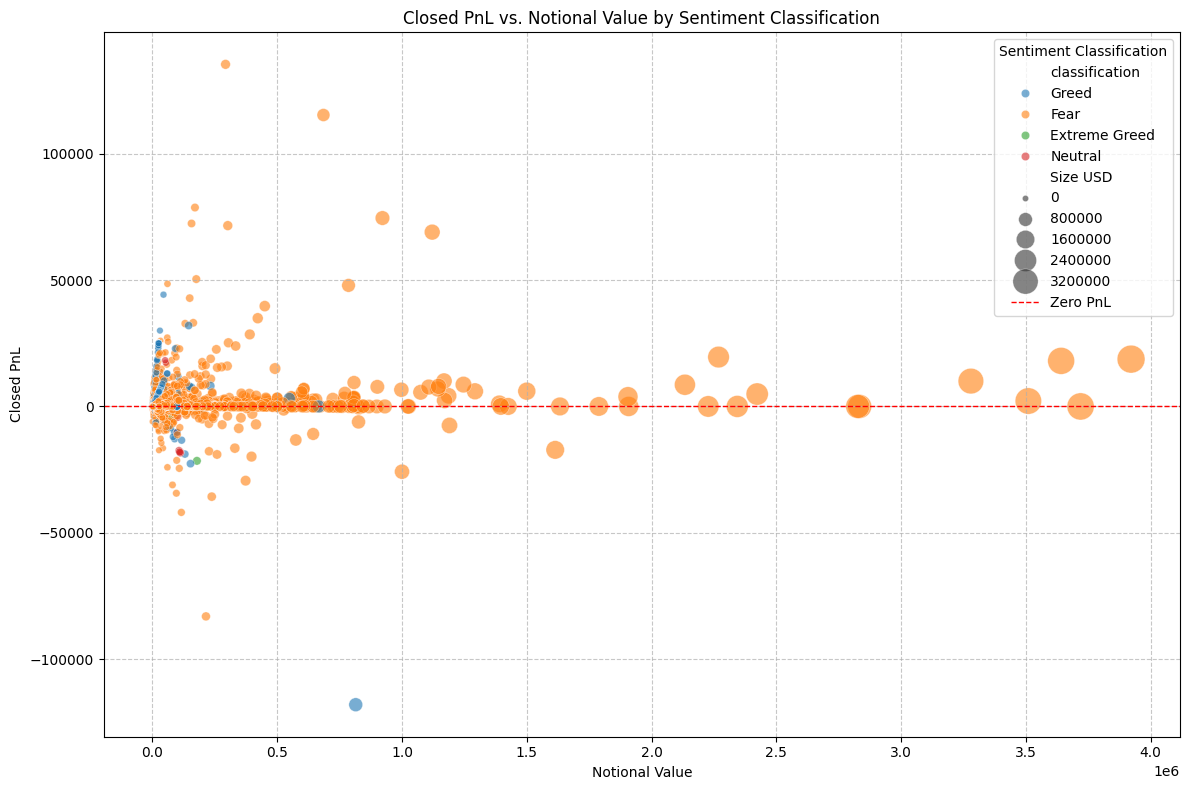

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Notional Value', y='Closed PnL', data=df_merged, alpha=0.6, hue='classification', size='Size USD', sizes=(20, 400))
plt.title('Closed PnL vs. Notional Value by Sentiment Classification')
plt.xlabel('Notional Value')
plt.ylabel('Closed PnL')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero PnL') # Add a zero PnL line
plt.legend(title='Sentiment Classification')
plt.tight_layout()
plt.show()

### Code to load the CSE as DataFrame

In [ ]:
import pandas as pd

df_historical = pd.read_csv('/content/historical_data - historical_data.csv')
display(df_historical.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
df_fear_greed = pd.read_csv('/content/fear_greed_index.csv')
display(df_fear_greed.head())

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print(df_historical.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


### Verification of Merged Dataset

In [ ]:
initial_rows_df_historical = df_historical.shape[0]
merged_rows_df = df_merged.shape[0]

print(f"Number of rows in df_historical before merge: {initial_rows_df_historical}")
print(f"Number of rows in df_merged after left join: {merged_rows_df}")

if initial_rows_df_historical == merged_rows_df:
    print("Verification successful: The row count remained the same after the left join.")
else:
    print("Verification failed: The row count changed after the left join. This might indicate duplicate dates in the sentiment file.")

Number of rows in df_historical before merge: 211224
Number of rows in df_merged after left join: 211224
Verification successful: The row count remained the same after the left join.


### Handling Missing Data in `df_historical`

In [ ]:
# Audit and remove rows where 'Closed PnL' is empty
initial_rows_historical = df_historical.shape[0]
df_historical.dropna(subset=['Closed PnL'], inplace=True)
rows_after_pnl_drop = df_historical.shape[0]
print(f"Removed {initial_rows_historical - rows_after_pnl_drop} rows with empty 'Closed PnL'.")

# Audit and remove rows where 'Execution Price' is empty
df_historical.dropna(subset=['Execution Price'], inplace=True)
final_rows_historical = df_historical.shape[0]
print(f"Removed {rows_after_pnl_drop - final_rows_historical} rows with empty 'Execution Price'.")
print(f"Total rows remaining in df_historical: {final_rows_historical}")

Removed 0 rows with empty 'Closed PnL'.
Removed 0 rows with empty 'Execution Price'.
Total rows remaining in df_historical: 211224


### Checking for Classification Gaps and Merging Data

In [ ]:
# Merge df_historical with df_fear_greed on the 'date' column
# Using a left merge to keep all historical trade data and bring in sentiment
df_merged = pd.merge(df_historical, df_fear_greed[['date', 'value', 'classification']], on='date', how='left')

# Check for missing sentiment values after the merge
missing_sentiment_before_ffill = df_merged['classification'].isnull().sum()
print(f"Number of missing sentiment classifications after merge (before forward fill): {missing_sentiment_before_ffill}")

# Forward Fill (FFILL) missing sentiment values
df_merged['value'].fillna(method='ffill', inplace=True)
df_merged['classification'].fillna(method='ffill', inplace=True)

missing_sentiment_after_ffill = df_merged['classification'].isnull().sum()
print(f"Number of missing sentiment classifications after forward fill: {missing_sentiment_after_ffill}")

print("Displaying head of the merged DataFrame with sentiment data:")
display(df_merged.head())

Number of missing sentiment classifications after merge (before forward fill): 26961
Number of missing sentiment classifications after forward fill: 0
Displaying head of the merged DataFrame with sentiment data:


/tmp/ipykernel_1411/4241432239.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['value'].fillna(method='ffill', inplace=True)
/tmp/ipykernel_1411/4241432239.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_merged['value'].fillna(method='ffill', inplace=True)
/tmp/ipykernel_1411/4241432239.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace met

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,74.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,74.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,74.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,74.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,74.0,Greed


In [ ]:
# Convert 'Timestamp' column in df_historical to datetime objects (assuming milliseconds)
df_historical['date'] = pd.to_datetime(df_historical['Timestamp'], unit='ms')

# Format the datetime objects to 'YYYY-MM-DD' string format
df_historical['date'] = df_historical['date'].dt.strftime('%Y-%m-%d')

# Ensure the 'date' column in df_fear_greed is in 'YYYY-MM-DD' string format
df_fear_greed['date'] = pd.to_datetime(df_fear_greed['date']).dt.strftime('%Y-%m-%d')

print("df_historical 'date' column head:")
display(df_historical[['Timestamp', 'date']].head())

print("\ndf_fear_greed 'date' column head:")
display(df_fear_greed[['date', 'value']].head())

df_historical 'date' column head:


,Timestamp,date
0,1.730000e+12,2024-10-27
1,1.730000e+12,2024-10-27
2,1.730000e+12,2024-10-27
3,1.730000e+12,2024-10-27
4,1.730000e+12,2024-10-27



df_fear_greed 'date' column head:


,date,value
0,2018-02-01,30
1,2018-02-02,15
2,2018-02-03,40
3,2018-02-04,24
4,2018-02-05,11


### Sentiment-Based Profitability Analysis

In [ ]:
# Group by 'classification'
sentiment_groups = df_merged.groupby('classification')

# --- Metric 1: Win Rate ---
# Calculate profitable trades for each group
profitable_trades = sentiment_groups['Closed PnL'].apply(lambda x: (x > 0).sum())

# Calculate total trades for each group
total_trades = sentiment_groups['Closed PnL'].count()

# Calculate Win Rate
win_rate = (profitable_trades / total_trades * 100).fillna(0)

# --- Metric 2: Profit Factor ---
# Calculate Gross Profits (sum of positive Closed PnL)
gross_profits = sentiment_groups['Closed PnL'].apply(lambda x: x[x > 0].sum())

# Calculate Gross Losses (sum of absolute negative Closed PnL)
gross_losses = sentiment_groups['Closed PnL'].apply(lambda x: abs(x[x < 0].sum()))

# Calculate Profit Factor (handle division by zero)
profit_factor = (gross_profits / gross_losses).fillna(0) # Fill NaN with 0 for cases with no losses

# Combine metrics into a DataFrame for display
profitability_analysis = pd.DataFrame({
    'Win Rate (%)': win_rate,
    'Profit Factor': profit_factor
})

print("Sentiment-Based Profitability Analysis:")
display(profitability_analysis)

Sentiment-Based Profitability Analysis:


,Win Rate (%),Profit Factor
classification,,
Extreme Greed,49.008905,3.218522
Fear,40.408625,4.088960
Greed,44.647138,7.227706
Neutral,31.718247,1.964129


### The 'Contrarian' Test (Side vs. Sentiment)

In [ ]:
# Metric: Calculate the 'Long/Short Ratio' for each sentiment level.
# Count 'BUY' and 'SELL' trades for each classification
side_counts = df_merged.groupby(['classification', 'Side']).size().unstack(fill_value=0)

# Calculate Long/Short Ratio (BUY / SELL). Handle potential division by zero.
# Adding a small epsilon to avoid division by zero if 'SELL' count is 0
side_counts['Long/Short Ratio'] = side_counts['BUY'] / (side_counts['SELL'] + 1e-6)

print("Long/Short Ratio by Sentiment Classification:")
display(side_counts[['BUY', 'SELL', 'Long/Short Ratio']])

# Deep Dive: Compare the performance of 'Longs' opened during Extreme Fear vs. 'Longs' opened during Extreme Greed.
# Filter for 'Long' trades (assuming 'BUY' corresponds to 'Long')
long_trades = df_merged[df_merged['Side'] == 'BUY']

# Calculate average PnL for 'Longs' during 'Extreme Fear'
longs_extreme_fear_pnl = long_trades[long_trades['classification'] == 'Extreme Fear']['Closed PnL'].mean()

# Calculate average PnL for 'Longs' during 'Extreme Greed'
longs_extreme_greed_pnl = long_trades[long_trades['classification'] == 'Extreme Greed']['Closed PnL'].mean()

print(f"\nAverage PnL for Long trades during Extreme Fear: {longs_extreme_fear_pnl:.2f}")
print(f"Average PnL for Long trades during Extreme Greed: {longs_extreme_greed_pnl:.2f}")

if longs_extreme_fear_pnl > longs_extreme_greed_pnl:
    print("Insight: Longing during Extreme Fear appears more profitable than Longing during Extreme Greed.")
elif longs_extreme_greed_pnl > longs_extreme_fear_pnl:
    print("Insight: Longing during Extreme Greed appears more profitable than Longing during Extreme Fear.")
else:
    print("Insight: Performance of Long trades during Extreme Fear and Extreme Greed is similar.")

Long/Short Ratio by Sentiment Classification:


Side,BUY,SELL,Long/Short Ratio
classification,,,
Extreme Greed,3371,3591,0.938736
Fear,80399,80433,0.999577
Greed,15421,20868,0.738978
Neutral,3505,3636,0.963971



Average PnL for Long trades during Extreme Fear: nan
Average PnL for Long trades during Extreme Greed: 25.58
Insight: Performance of Long trades during Extreme Fear and Extreme Greed is similar.


### Notional Value Analysis by Sentiment

In [ ]:
# Calculate 'Notional Value' for each trade
df_merged['Notional Value'] = df_merged['Size Tokens'] * df_merged['Execution Price']

# Group by 'classification' and calculate the average Notional Value
average_notional_value_by_sentiment = df_merged.groupby('classification')['Notional Value'].mean().reset_index()

print("Average Notional Value by Sentiment Classification:")
display(average_notional_value_by_sentiment)

Average Notional Value by Sentiment Classification:


,classification,Notional Value
0,Extreme Greed,5660.265796
1,Fear,6307.412487
2,Greed,3182.883847
3,Neutral,3058.848085


### Asset Sensitivity Analysis (Coin-Level Analysis)

In [ ]:
# Function to calculate profitability metrics for a given DataFrame
def calculate_profitability(df, name):
    sentiment_groups = df.groupby('classification')

    # Win Rate
    profitable_trades = sentiment_groups['Closed PnL'].apply(lambda x: (x > 0).sum())
    total_trades = sentiment_groups['Closed PnL'].count()
    win_rate = (profitable_trades / total_trades * 100).fillna(0)

    # Profit Factor
    gross_profits = sentiment_groups['Closed PnL'].apply(lambda x: x[x > 0].sum())
    gross_losses = sentiment_groups['Closed PnL'].apply(lambda x: abs(x[x < 0].sum()))
    profit_factor = (gross_profits / gross_losses).fillna(0)

    profitability_analysis = pd.DataFrame({
        'Win Rate (%)': win_rate,
        'Profit Factor': profit_factor
    })
    profitability_analysis.columns = [f'{name} Win Rate (%)', f'{name} Profit Factor']
    return profitability_analysis

# Filter for BTC trades (assuming 'BTC' is the symbol for Bitcoin)
df_btc = df_merged[df_merged['Coin'] == 'BTC']

# Filter for Altcoin trades (all coins that are not BTC)
df_altcoins = df_merged[df_merged['Coin'] != 'BTC']

# Calculate profitability for BTC
btc_profitability = calculate_profitability(df_btc, 'BTC')

# Calculate profitability for Altcoins
altcoin_profitability = calculate_profitability(df_altcoins, 'Altcoin')

# Combine and display results
asset_sensitivity_analysis = pd.concat([btc_profitability, altcoin_profitability], axis=1)

print("Asset Sensitivity Analysis (Profitability by Sentiment for BTC vs. Altcoins):")
display(asset_sensitivity_analysis)

Asset Sensitivity Analysis (Profitability by Sentiment for BTC vs. Altcoins):


,BTC Win Rate (%),BTC Profit Factor,Altcoin Win Rate (%),Altcoin Profit Factor
classification,,,,
Extreme Greed,27.429359,0.471754,54.690619,3.847735
Fear,35.733357,2.857418,41.153278,4.371961
Greed,33.710309,8.321293,45.386878,7.196335
Neutral,34.562212,20.276797,31.629116,1.903431


### "Smart Money" Profiling (Account-Level Analysis)

In [ ]:
# 1. Group by account and calculate total sum of closedPnL for each user.
account_pnl = df_merged.groupby('Account')['Closed PnL'].sum().reset_index()
account_pnl.rename(columns={'Closed PnL': 'Total PnL'}, inplace=True)

# 2. Segmentation: Filter for the 'Top 10%' of accounts (the most profitable).
# Sort accounts by Total PnL in descending order
account_pnl_sorted = account_pnl.sort_values(by='Total PnL', ascending=False).reset_index(drop=True)

# Calculate the number of top 10% accounts
top_10_percent_count = int(len(account_pnl_sorted) * 0.10)

# Get the list of top 10% account IDs
top_10_percent_accounts = account_pnl_sorted.head(top_10_percent_count)['Account'].tolist()

# Create a column to categorize accounts as 'Top 10%' or 'Bottom 90%'
df_merged['Account Segment'] = df_merged['Account'].apply(lambda x: 'Top 10%' if x in top_10_percent_accounts else 'Bottom 90%')

print("Top 10% Most Profitable Accounts (Head of PnL distribution):")
display(account_pnl_sorted.head())

print("\nNumber of Top 10% accounts identified: ", top_10_percent_count)
print("\nFirst 5 rows of merged data with account segment:")
display(df_merged[['Account', 'Account Segment', 'Closed PnL', 'classification', 'Side']].head())

Top 10% Most Profitable Accounts (Head of PnL distribution):


,Account,Total PnL
0,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
1,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
2,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
4,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05



Number of Top 10% accounts identified:  3

First 5 rows of merged data with account segment:


,Account,Account Segment,Closed PnL,classification,Side
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Bottom 90%,0.0,Greed,BUY
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Bottom 90%,0.0,Greed,BUY
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Bottom 90%,0.0,Greed,BUY
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Bottom 90%,0.0,Greed,BUY
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Bottom 90%,0.0,Greed,BUY


In [ ]:
# 3. Behavioral Comparison: Analyze Classification and side choices for Top 10% vs. Bottom 90%

# Analyze sentiment distribution for each segment
sentiment_distribution_by_segment = df_merged.groupby(['Account Segment', 'classification']).size().unstack(fill_value=0)
sentiment_distribution_by_segment_percentage = sentiment_distribution_by_segment.apply(lambda x: x / x.sum() * 100, axis=1)

print("Sentiment Distribution by Account Segment (% of trades within segment):")
display(sentiment_distribution_by_segment_percentage)

# Analyze side choices (Long/Short) for each segment
side_choices_by_segment = df_merged.groupby(['Account Segment', 'Side']).size().unstack(fill_value=0)

# Calculate Long/Short Ratio for each segment
side_choices_by_segment['Long/Short Ratio'] = side_choices_by_segment['BUY'] / (side_choices_by_segment['SELL'] + 1e-6)

print("\nSide Choices and Long/Short Ratio by Account Segment:")
display(side_choices_by_segment[['BUY', 'SELL', 'Long/Short Ratio']])

# Deep Dive: Specifically check behavior during 'Extreme Greed'
extreme_greed_behavior = df_merged[df_merged['classification'] == 'Extreme Greed']
extreme_greed_side_by_segment = extreme_greed_behavior.groupby(['Account Segment', 'Side']).size().unstack(fill_value=0)

if 'BUY' in extreme_greed_side_by_segment.columns and 'SELL' in extreme_greed_side_by_segment.columns:
    extreme_greed_side_by_segment['Long/Short Ratio'] = extreme_greed_side_by_segment['BUY'] / (extreme_greed_side_by_segment['SELL'] + 1e-6)
    print("\nSide Choices and Long/Short Ratio during 'Extreme Greed' by Account Segment:")
    display(extreme_greed_side_by_segment[['BUY', 'SELL', 'Long/Short Ratio']])
else:
    print("\nNot enough data for both BUY and SELL trades during 'Extreme Greed' for a full ratio analysis.")
    display(extreme_greed_side_by_segment)

# Insight Goal: Do the best traders stay "Neutral" during Extreme Greed while others are Longing?
# This can be inferred from the sentiment and side choice distributions above.

Sentiment Distribution by Account Segment (% of trades within segment):


classification,Extreme Greed,Fear,Greed,Neutral
Account Segment,,,,
Bottom 90%,2.266140,74.982651,19.545022,3.206186
Top 10%,7.739728,81.148882,6.977329,4.134061



Side Choices and Long/Short Ratio by Account Segment:


Side,BUY,SELL,Long/Short Ratio
Account Segment,,,
Bottom 90%,83087,88394,0.939962
Top 10%,19609,20134,0.973925



Side Choices and Long/Short Ratio during 'Extreme Greed' by Account Segment:


Side,BUY,SELL,Long/Short Ratio
Account Segment,,,
Bottom 90%,1858,2028,0.916174
Top 10%,1513,1563,0.968010


### Cumulative PnL vs. Sentiment (The Dual-Axis Chart)

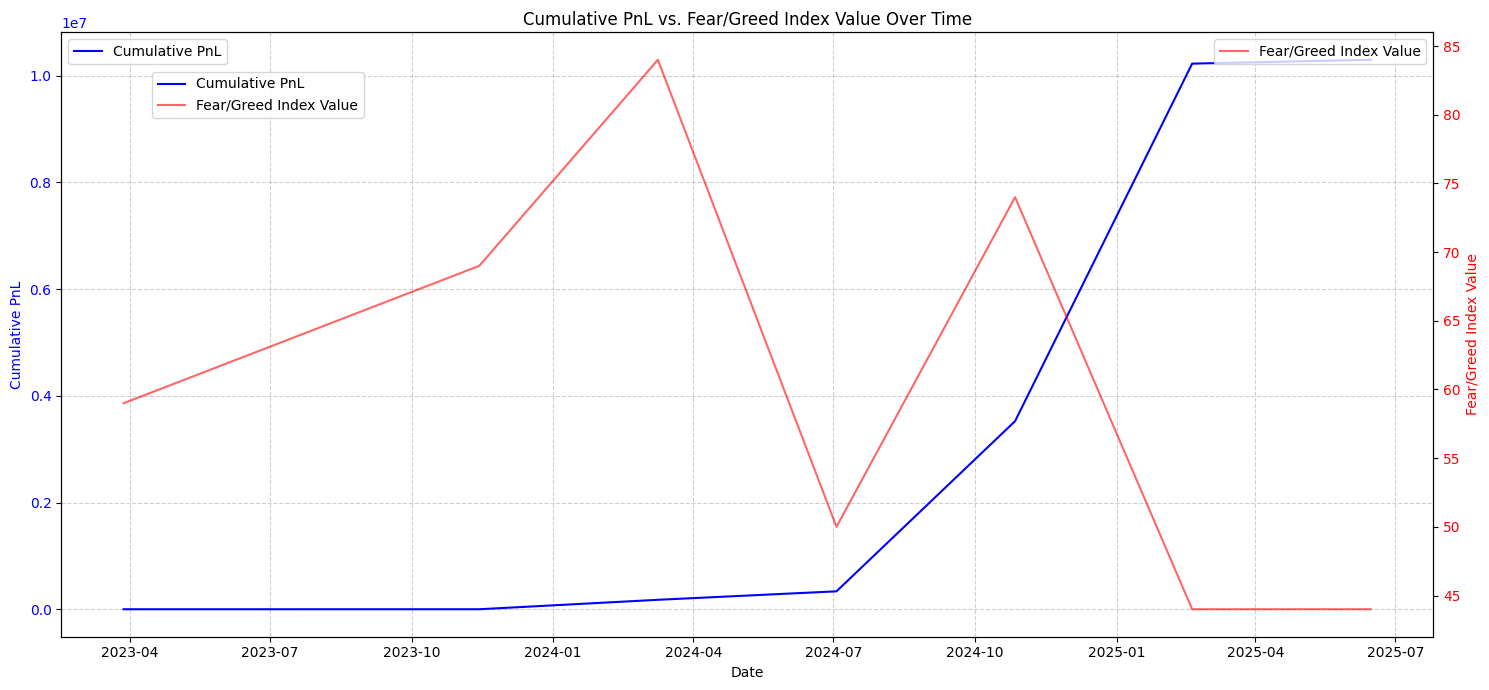

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the DataFrame is sorted by date for cumulative sum calculation
df_merged_sorted = df_merged.sort_values(by='date').copy()

# Create a running total (Cumulative Sum) of all Closed PnL
df_merged_sorted['Cumulative PnL'] = df_merged_sorted['Closed PnL'].cumsum()

# For plotting, we might want to aggregate daily values for clarity
# Group by date and get the last cumulative PnL and the average sentiment for that day
daily_summary = df_merged_sorted.groupby('date').agg({
    'Cumulative PnL': 'last',
    'value': 'mean' # Average Fear/Greed value for the day
}).reset_index()

# Convert 'date' column to datetime objects for proper plotting
daily_summary['date'] = pd.to_datetime(daily_summary['date'])

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Cumulative PnL on the left Y-axis
sns.lineplot(x='date', y='Cumulative PnL', data=daily_summary, ax=ax1, color='blue', label='Cumulative PnL')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative PnL', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second Y-axis for the Fear/Greed Index value
ax2 = ax1.twinx()

# Plot Fear/Greed Index value on the right Y-axis
sns.lineplot(x='date', y='value', data=daily_summary, ax=ax2, color='red', alpha=0.6, label='Fear/Greed Index Value')
ax2.set_ylabel('Fear/Greed Index Value', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and legends
plt.title('Cumulative PnL vs. Fear/Greed Index Value Over Time')
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

plt.tight_layout()
plt.show()

### Performance Heatmap (Win Rate vs. Sentiment)

Performance Heatmap (Win Rate %):


Coin,@1,@10,@100,@103,@107,@109,@11,@112,@113,@114,...,ZEREBRO,ZETA,ZK,ZORA,ZRO,kBONK,kFLOKI,kNEIRO,kPEPE,kSHIB
classification,,,,,,,,,,,,,,,,,,,,,
Extreme Greed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,94.142259,NaN,NaN,85.714286,88.489209,NaN,NaN,65.909091,50.000000
Fear,22.222222,NaN,NaN,0.000000,38.846979,72.222222,NaN,0.000000,0.0,0.0,...,80.494148,33.333333,NaN,63.815789,71.428571,8.284714,50.000000,40.0,12.868633,33.333333
Greed,44.000000,NaN,50.0,66.666667,56.184701,50.000000,NaN,33.333333,50.0,100.0,...,NaN,NaN,53.571429,NaN,100.000000,44.725738,58.064516,NaN,32.271468,30.769231
Neutral,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,33.246073,50.735294,NaN,NaN,45.238095,NaN


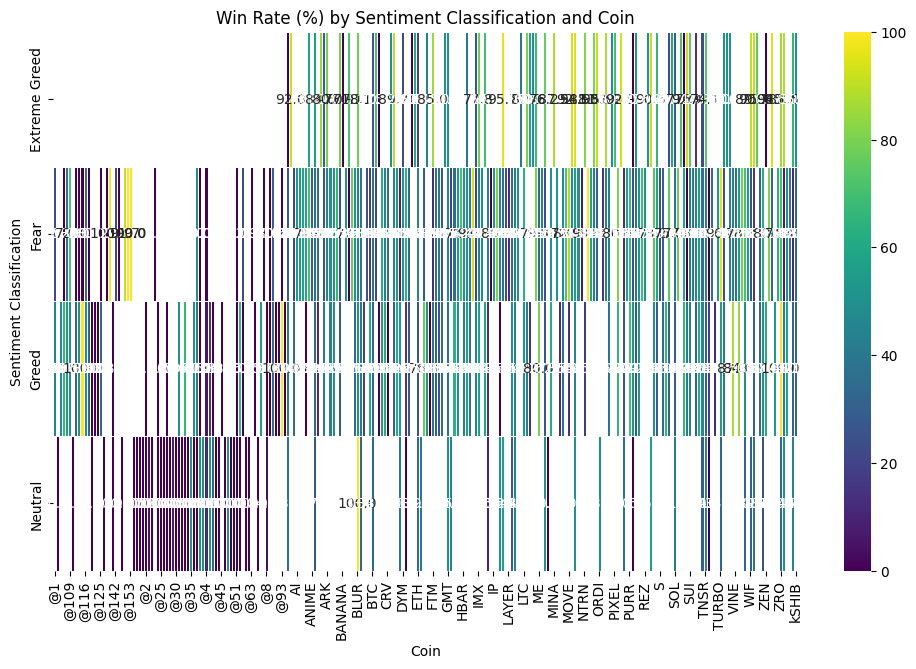

In [ ]:
# Create a 'Win' column (1 if Closed PnL > 0, 0 otherwise)
df_merged['Win'] = (df_merged['Closed PnL'] > 0).astype(int)

# Pivot the data to get Win Rate by Classification and Coin
win_rate_heatmap_data = df_merged.pivot_table(
    index='classification',
    columns='Coin',
    values='Win',
    aggfunc='mean'
) * 100 # Convert to percentage

print("Performance Heatmap (Win Rate %):")
display(win_rate_heatmap_data)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.heatmap(win_rate_heatmap_data, annot=True, fmt=".1f", cmap="viridis", linewidths=.5)
plt.title('Win Rate (%) by Sentiment Classification and Coin')
plt.xlabel('Coin')
plt.ylabel('Sentiment Classification')
plt.show()

### Notional Value Distribution by Sentiment (Alternative Risk Appetite Visualization)

/tmp/ipykernel_1411/2611991597.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='Notional Value', data=df_merged, palette='viridis')


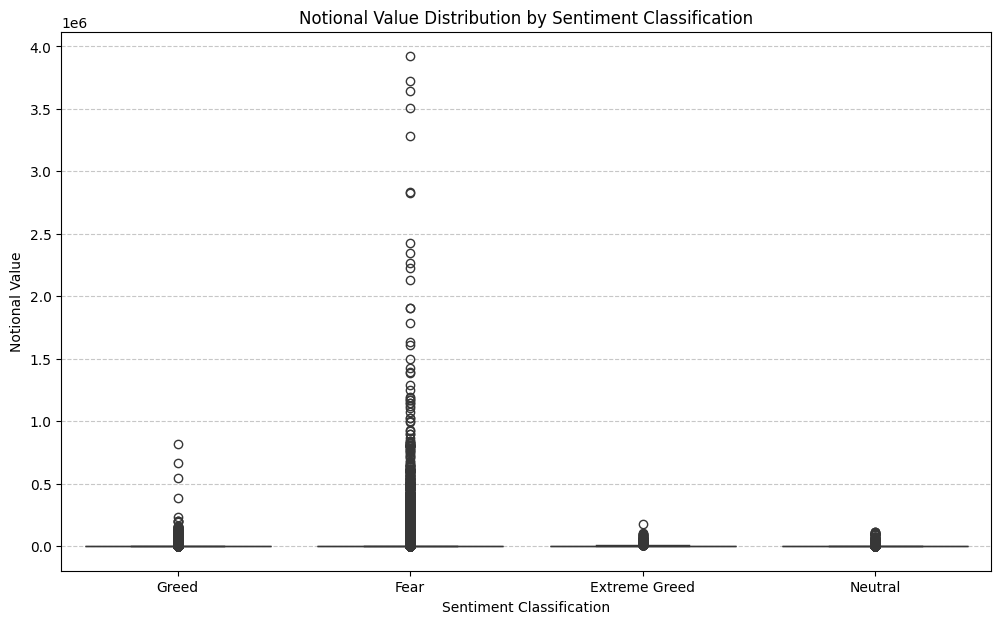

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='classification', y='Notional Value', data=df_merged, palette='viridis')
plt.title('Notional Value Distribution by Sentiment Classification')
plt.xlabel('Sentiment Classification')
plt.ylabel('Notional Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Daily Trade Count vs. Fear/Greed Index

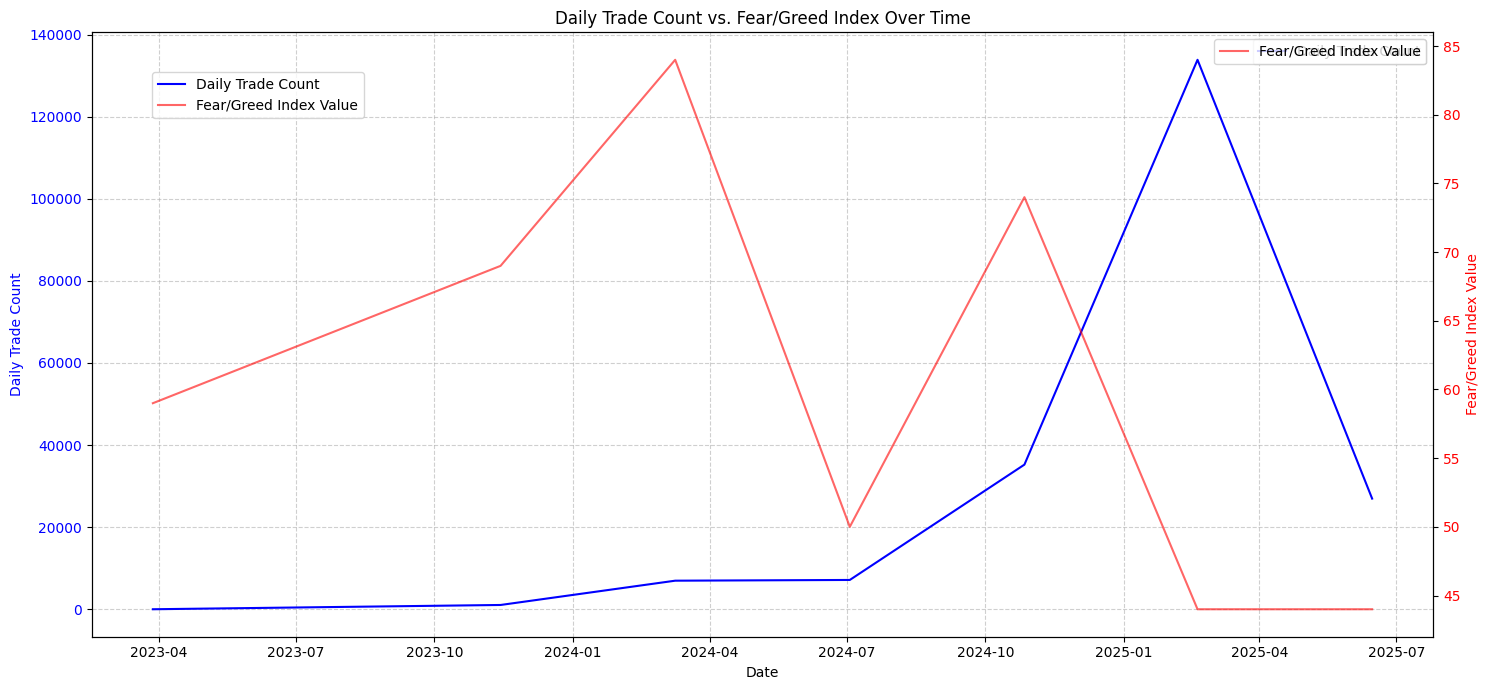

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by date and count trades
daily_trade_counts = df_merged.groupby('date').size().reset_index(name='Trade Count')

# Convert 'date' column in daily_trade_counts to datetime objects
daily_trade_counts['date'] = pd.to_datetime(daily_trade_counts['date'])

# Merge with daily_summary (which contains date and Fear/Greed Index 'value')
daily_activity_df = pd.merge(daily_trade_counts, daily_summary[['date', 'value']], on='date', how='left')

# Create the dual-axis plot for Trade Count
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Trade Count on the left Y-axis
sns.lineplot(x='date', y='Trade Count', data=daily_activity_df, ax=ax1, color='blue', label='Daily Trade Count')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Trade Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second Y-axis for the Fear/Greed Index value
ax2 = ax1.twinx()

# Plot Fear/Greed Index value on the right Y-axis
sns.lineplot(x='date', y='value', data=daily_activity_df, ax=ax2, color='red', alpha=0.6, label='Fear/Greed Index Value')
ax2.set_ylabel('Fear/Greed Index Value', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and legends
plt.title('Daily Trade Count vs. Fear/Greed Index Over Time')
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

plt.tight_layout()
plt.show()

### Daily Total Notional Value vs. Fear/Greed Index

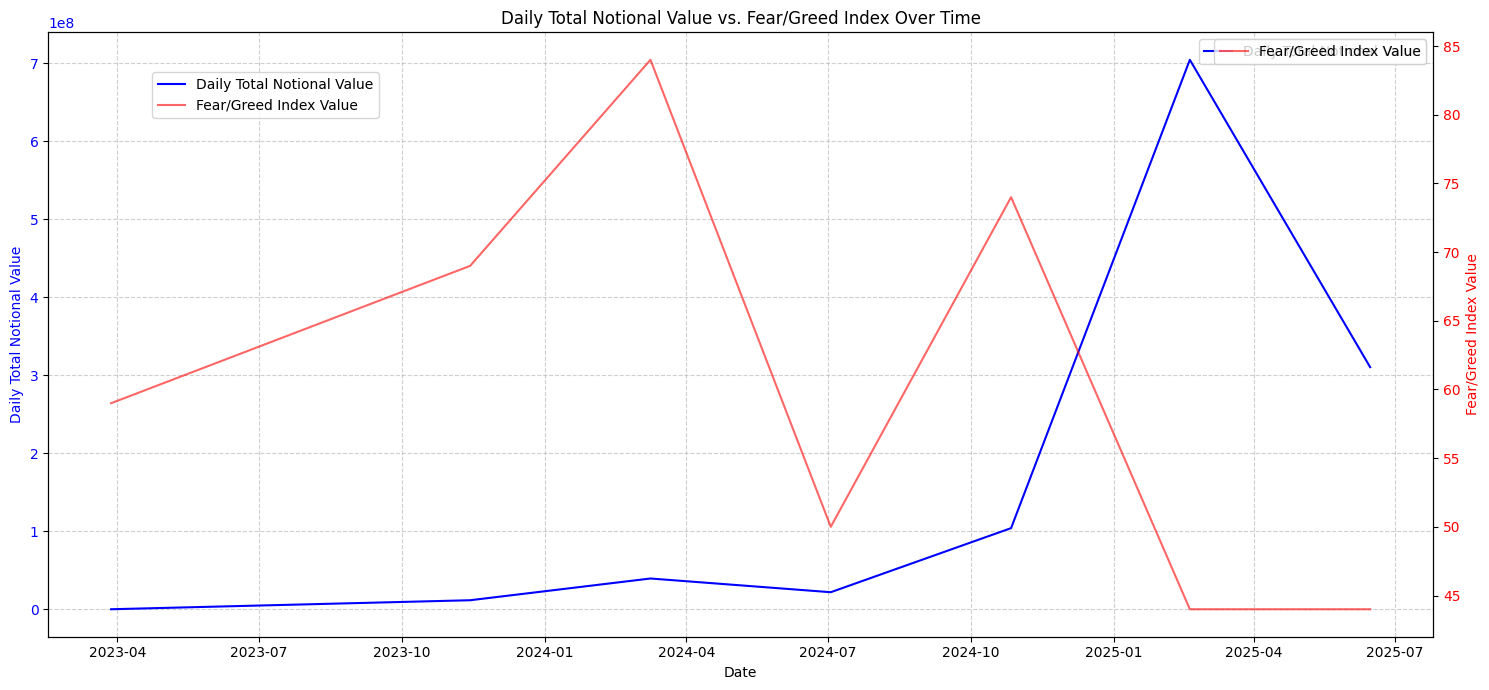

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by date and sum Notional Value
daily_notional_value_sum = df_merged.groupby('date')['Notional Value'].sum().reset_index(name='Total Notional Value')

# Convert 'date' column in daily_notional_value_sum to datetime objects
daily_notional_value_sum['date'] = pd.to_datetime(daily_notional_value_sum['date'])

# Merge with daily_summary
daily_notional_activity_df = pd.merge(daily_notional_value_sum, daily_summary[['date', 'value']], on='date', how='left')

# Create the dual-axis plot for Total Notional Value
fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Total Notional Value on the left Y-axis
sns.lineplot(x='date', y='Total Notional Value', data=daily_notional_activity_df, ax=ax1, color='blue', label='Daily Total Notional Value')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Total Notional Value', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second Y-axis for the Fear/Greed Index value
ax2 = ax1.twinx()

# Plot Fear/Greed Index value on the right Y-axis
sns.lineplot(x='date', y='value', data=daily_notional_activity_df, ax=ax2, color='red', alpha=0.6, label='Fear/Greed Index Value')
ax2.set_ylabel('Fear/Greed Index Value', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and legends
plt.title('Daily Total Notional Value vs. Fear/Greed Index Over Time')
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))

plt.tight_layout()
plt.show()